# Exploratory analysis — dengue UF × epidemiological week

Document the forecasting panel and the series properties that justify Phase 1
modelling choices (log-scale metrics, `m = 52`, named extreme seasons).

1. **Dataset** — SINAN → probable UF × epidemiological-week panel
2. **Panel integrity** — coverage, zero-fill, dengue seasons vs eval protocol
3. **Series properties** — overdispersion, annual period, 2024 / extreme seasons, qualitative non-stationarity
4. **Figures** — EW × year heatmaps (counts and IBGE cases/million; west → east)
5. **Takeaways** — article-ready sentences from the numbers above

## Setup

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from arboviruses_series_forecasting.data.epidemiological.aggregate import (
    aggregate_by_uf_and_onset_week,
    complete_uf_week_panel,
)
from arboviruses_series_forecasting.data.epidemiological.load import load_sinan_cases
from arboviruses_series_forecasting.data.epidemiological.probable import (
    keep_probable_cases,
)
from arboviruses_series_forecasting.data.epidemiological.seasons import (
    add_season_end_year,
    complete_season_end_years,
    held_out_season_end_years,
)
from arboviruses_series_forecasting.data.epidemiological.window import (
    clip_to_study_window,
    drop_right_censored_weeks,
    epiweek_of,
)

REPO_ROOT = Path("..").resolve()
CONFIG_PATH = REPO_ROOT / "config.yml"

with CONFIG_PATH.open() as f:
    config = yaml.safe_load(f)

SINAN_PATH = REPO_ROOT / config["data"]["sinan"]["path"]
PROCESSED_PATH = REPO_ROOT / config["paths"]["processed"] / "dengue_uf_ew.parquet"
FIGURES_DIR = REPO_ROOT / config["paths"]["figures"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

agg_cfg = config["aggregation"]
eval_cfg = config["evaluation"]
WINDOW_START = agg_cfg["window"]["start"]
RIGHT_CENSOR_WEEKS = int(agg_cfg["right_censor_weeks"])
SEASON_START = int(agg_cfg["season_boundary"]["start"])
SEASON_END = int(agg_cfg["season_boundary"]["end"])
HORIZONS = list(eval_cfg["horizons"])
TRAIN_YEARS = int(eval_cfg["training_window_years"])
HELD_OUT_SEASONS = int(eval_cfg["held_out_seasons"])

# Approximate UF centroid longitudes (°E) — west → east ordering for facets.
UF_LONGITUDE = {
    "AC": -70.55, "AM": -64.66, "RO": -63.07, "RR": -61.40, "PA": -52.29,
    "AP": -51.77, "MT": -55.98, "MS": -54.54, "TO": -48.30, "GO": -49.31,
    "DF": -47.93, "MA": -45.27, "PI": -42.80, "BA": -41.70, "MG": -44.38,
    "SP": -48.78, "PR": -51.55, "SC": -50.95, "RS": -53.00, "ES": -40.31,
    "RJ": -42.66, "CE": -39.32, "RN": -36.72, "PB": -36.72, "PE": -37.99,
    "AL": -36.62, "SE": -37.07,
}
UFS_WEST_TO_EAST = sorted(UF_LONGITUDE, key=UF_LONGITUDE.get)


def nature_style() -> None:
    mpl.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "lines.linewidth": 1.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


nature_style()
pd.set_option("display.width", 120)

assert SINAN_PATH.exists(), f"Missing extract: {SINAN_PATH}"
print(f"sinan:     {SINAN_PATH}")
print(f"processed: {PROCESSED_PATH}")
print(f"figures:   {FIGURES_DIR}")
print(
    f"eval:      horizons={HORIZONS}, train={TRAIN_YEARS}y, "
    f"held-out={HELD_OUT_SEASONS} seasons (EW{SEASON_START}→EW{SEASON_END})"
)

sinan:     /home/caioolubini/Projects/arboviruses-series-forecasting/data/raw/SINAN_dengue_cases.parquet
processed: /home/caioolubini/Projects/arboviruses-series-forecasting/data/processed/dengue_uf_ew.parquet
figures:   /home/caioolubini/Projects/arboviruses-series-forecasting/docs/figures
eval:      horizons=[4, 12], train=6y, held-out=2 seasons (EW41→EW40)


## Dataset — SINAN to forecasting panel

Target grain is UF × epidemiological week (IMDC-aligned): probable dengue counts by
symptom-onset week. Rules come from `config.yml`.

| Rule | Detail |
|---|---|
| Probable cases | Drop discarded (`CLASSI_FIN = 5`); keep other / missing classifications |
| Timing | Symptom-onset epidemiological week (Sunday start) |
| Geography | 27 federative units |
| Window | From `2010-EW01` through last complete week in the extract |
| Right-censor | Drop final 12 weeks (open SINAN snapshot is downward-biased) |
| Panel completion | Missing UF×week cells filled with 0 for a regular series |

In [2]:
raw = load_sinan_cases(SINAN_PATH)
probable = keep_probable_cases(raw)
weekly = aggregate_by_uf_and_onset_week(probable)
started = clip_to_study_window(weekly, start=WINDOW_START)
observed = drop_right_censored_weeks(started, n_weeks=RIGHT_CENSOR_WEEKS)
dengue = complete_uf_week_panel(observed)

dengue = pd.concat([dengue, epiweek_of(dengue["week_start"])], axis=1)
dengue["log10_cases"] = np.log10(dengue["cases"] + 1)

n_observed_cells = len(observed)
n_panel_cells = len(dengue)
n_zero_filled = n_panel_cells - n_observed_cells
zero_fill_rate = n_zero_filled / n_panel_cells

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
dengue.to_parquet(PROCESSED_PATH, index=False)

stages = pd.DataFrame(
    [
        ("raw extract rows", len(raw)),
        ("probable rows", len(probable)),
        ("observed UF×week cells (post-window/censor)", n_observed_cells),
        ("completed panel cells", n_panel_cells),
        ("zero-filled cells", n_zero_filled),
    ],
    columns=["stage", "n"],
).set_index("stage")

portrait = pd.Series(
    {
        "ufs": dengue["uf"].nunique(),
        "weeks": dengue["week_start"].nunique(),
        "span": f"{dengue['week_start'].min().date()} → {dengue['week_start'].max().date()}",
        "total_probable_cases": f"{int(dengue['cases'].sum()):,}",
        "zero_fill_rate": f"{zero_fill_rate:.2%}",
        "saved": str(PROCESSED_PATH.relative_to(REPO_ROOT)),
    },
    name="value",
).to_frame()

data_dictionary = pd.DataFrame(
    [
        ("uf", "str", "Federative unit abbreviation (27 UFs)"),
        ("week_start", "datetime64[ns]", "Sunday start of the epidemiological week"),
        ("cases", "int64", "Probable dengue count (onset week); 0 if zero-filled"),
        ("ew_year", "int", "CDC-style epiweek year"),
        ("ew", "int", "Epidemiological week number (1–53)"),
        ("log10_cases", "float", "log10(cases + 1) for figures"),
    ],
    columns=["column", "dtype", "description"],
).set_index("column")

display(stages)
display(portrait)
display(data_dictionary)

,n
stage,
raw extract rows,1057243
probable rows,802169
observed UF×week cells (post-window/censor),22669
completed panel cells,22977
zero-filled cells,308


,value
ufs,27
weeks,851
span,2010-01-03 → 2026-04-19
total_probable_cases,"22,657,574"
zero_fill_rate,1.34%
saved,data/processed/dengue_uf_ew.parquet


,dtype,description
column,,
uf,str,Federative unit abbreviation (27 UFs)
week_start,datetime64[ns],Sunday start of the epidemiological week
cases,int64,Probable dengue count (onset week); 0 if zero-...
ew_year,int,CDC-style epiweek year
ew,int,Epidemiological week number (1–53)
log10_cases,float,log10(cases + 1) for figures


## Panel integrity for forecasting

Baselines assume a regular UF×week panel and hold out the last complete dengue seasons
(EW41→EW40), with a fixed multi-year training window. Confirm that assumption here before
interpreting series properties.

In [3]:
ufs = sorted(dengue["uf"].unique())
week_starts = pd.DatetimeIndex(sorted(dengue["week_start"].unique()))
expected_weeks = pd.date_range(week_starts.min(), week_starts.max(), freq="W-SUN")

assert len(ufs) == 27, f"Expected 27 UFs, found {len(ufs)}"
assert week_starts.equals(expected_weeks), "week_start is not a contiguous W-SUN grid"
assert len(dengue) == len(ufs) * len(week_starts), "panel has missing UF×week cells"
assert dengue.duplicated(["uf", "week_start"]).sum() == 0

cases_by_uf = dengue.groupby("uf")["cases"]
sparsity = pd.DataFrame(
    {
        "weeks": cases_by_uf.size(),
        "zero_weeks": cases_by_uf.apply(lambda s: int((s == 0).sum())),
        "zero_share": cases_by_uf.apply(lambda s: float((s == 0).mean())),
        "mean_cases": cases_by_uf.mean(),
    }
).reindex(UFS_WEST_TO_EAST)

dengue = add_season_end_year(dengue, season_start=SEASON_START)
complete_seasons = complete_season_end_years(
    dengue, season_start=SEASON_START, season_end=SEASON_END
)
held_out = held_out_season_end_years(
    dengue,
    n_seasons=HELD_OUT_SEASONS,
    season_start=SEASON_START,
    season_end=SEASON_END,
)
train_seasons = [s for s in complete_seasons if s not in held_out]

print(
    f"Regular panel: {len(ufs)} UFs × {len(week_starts)} weeks "
    f"({week_starts.min().date()} → {week_starts.max().date()})"
)
print(
    f"Zero-fill: {n_zero_filled:,} / {n_panel_cells:,} cells ({zero_fill_rate:.2%}); "
    f"median UF zero-week share {sparsity['zero_share'].median():.1%}"
)
print(
    f"Complete dengue seasons (EW{SEASON_START}→EW{SEASON_END}): {complete_seasons}"
)
print(
    f"Held-out seasons (last {HELD_OUT_SEASONS}): {held_out}; "
    f"earlier complete seasons available for train: {len(train_seasons)} "
    f"(protocol train window = {TRAIN_YEARS}y; horizons = {HORIZONS} weeks)"
)

sparsity[["zero_weeks", "zero_share", "mean_cases"]].assign(
    zero_share=lambda d: (d["zero_share"] * 100).round(1),
    mean_cases=lambda d: d["mean_cases"].round(1),
).rename(columns={"zero_share": "zero_weeks_%"})

Regular panel: 27 UFs × 851 weeks (2010-01-03 → 2026-04-19)
Zero-fill: 308 / 22,977 cells (1.34%); median UF zero-week share 0.0%
Complete dengue seasons (EW41→EW40): [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Held-out seasons (last 2): [2024, 2025]; earlier complete seasons available for train: 13 (protocol train window = 6y; horizons = [4, 12] weeks)


,zero_weeks,zero_weeks_%,mean_cases
uf,,,
AC,0,0.0,193.7
AM,0,0.0,188.6
RO,0,0.0,107.0
RR,75,8.8,21.7
MT,0,0.0,463.2
MS,0,0.0,568.2
RS,85,10.0,524.7
PA,0,0.0,191.5
AP,25,2.9,39.4


## Series properties → modelling choices

Three checks unlock Methods sentences and baseline choices; a fourth note states the
stationarity question for examiners without running unit-root tests.

### 1. Overdispersion

Per-UF variance-to-mean ratio (VMR). Values ≫ 1 mean raw-scale MAE is dominated by
high-burden UFs and epidemic weeks → score and model on `log1p`.

Across UFs, weekly VMR ranges from 105 to 44933 (median 1129) — far above 1, so counts are strongly overdispersed.


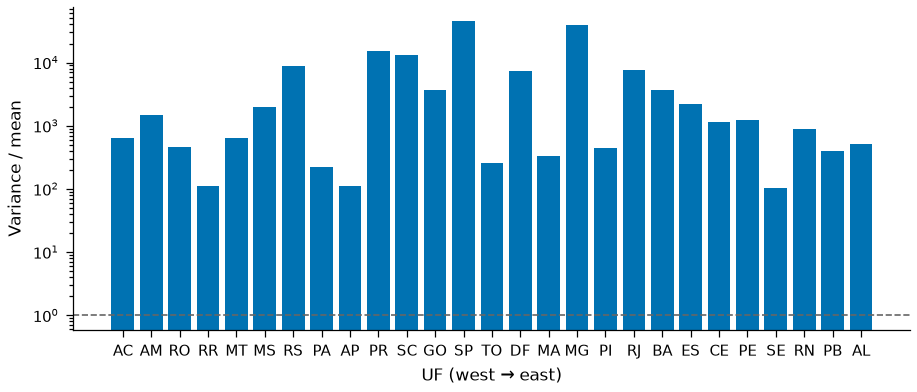

,mean,var,vmr
uf,,,
SE,54.1,5685.4,105.2
RR,21.7,2370.8,109.5
AP,39.4,4378.1,111.0
PA,191.5,41897.5,218.8
TO,158.6,40481.3,255.2
MA,134.6,44226.8,328.5
PB,261.7,105392.1,402.7
PI,174.1,77927.4,447.5
RO,107.0,49727.3,464.9


In [4]:
vmr = (
    dengue.groupby("uf")["cases"]
    .agg(mean="mean", var="var")
    .assign(vmr=lambda d: d["var"] / d["mean"])
    .sort_values("vmr")
)

vmr_min, vmr_max = float(vmr["vmr"].min()), float(vmr["vmr"].max())
vmr_median = float(vmr["vmr"].median())
print(
    f"Across UFs, weekly VMR ranges from {vmr_min:.0f} to {vmr_max:.0f} "
    f"(median {vmr_median:.0f}) — far above 1, so counts are strongly overdispersed."
)

fig, ax = plt.subplots(figsize=(7.2, 2.8))
ordered = vmr.reindex([uf for uf in UFS_WEST_TO_EAST if uf in vmr.index])
ax.bar(ordered.index, ordered["vmr"], color="#0072B2", width=0.8)
ax.set_ylabel("Variance / mean")
ax.set_xlabel("UF (west → east)")
ax.set_yscale("log")
ax.axhline(1.0, color="0.4", lw=0.8, ls="--")
ax.tick_params(axis="x", labelrotation=0)
fig.savefig(FIGURES_DIR / "eda_overdispersion_vmr.pdf")
fig.savefig(FIGURES_DIR / "eda_overdispersion_vmr.png")
plt.show()

vmr[["mean", "var", "vmr"]].round(1)

### 2. Annual periodicity

Mean seasonal profile (years before 2024) and autocorrelation on `log1p` at lags 52 vs 26.
A yearly peak and stronger lag-52 autocorrelation justify `m = 52` for seasonal naive and
Fourier terms.

Mean seasonal profile (2010–2023) peaks at EW15 and troughs at EW39; median UF autocorr of log1p counts is 0.51 at lag 52 vs -0.13 at lag 26 — annual period m = 52.


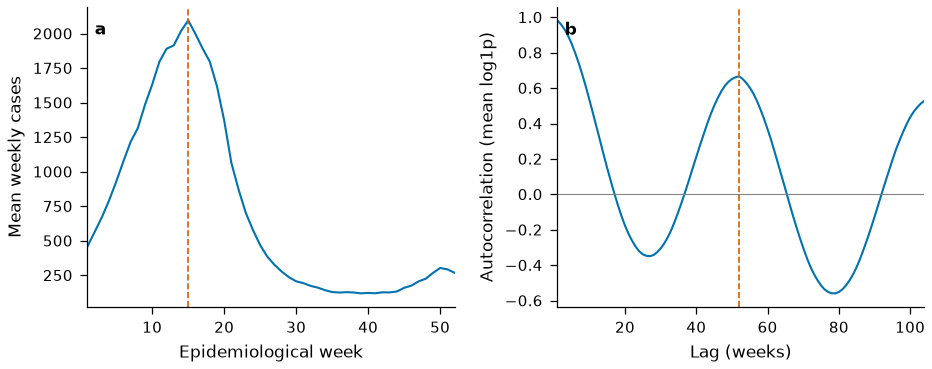

In [5]:
dengue["log1p_cases"] = np.log1p(dengue["cases"])

pre_2024 = dengue.loc[dengue["ew_year"] < 2024]
seasonal = (
    pre_2024.groupby("ew", as_index=False)["cases"]
    .mean()
    .query("ew <= 52")
)
peak_ew = int(seasonal.loc[seasonal["cases"].idxmax(), "ew"])
trough_ew = int(seasonal.loc[seasonal["cases"].idxmin(), "ew"])

acf52 = dengue.groupby("uf")["log1p_cases"].apply(lambda s: s.autocorr(lag=52))
acf26 = dengue.groupby("uf")["log1p_cases"].apply(lambda s: s.autocorr(lag=26))
acf52_median = float(acf52.median())
acf26_median = float(acf26.median())

print(
    f"Mean seasonal profile (2010–2023) peaks at EW{peak_ew} and troughs at EW{trough_ew}; "
    f"median UF autocorr of log1p counts is {acf52_median:.2f} at lag 52 "
    f"vs {acf26_median:.2f} at lag 26 — annual period m = 52."
)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6), gridspec_kw={"wspace": 0.28})

axes[0].plot(seasonal["ew"], seasonal["cases"], color="#0072B2")
axes[0].axvline(peak_ew, color="#D55E00", lw=0.8, ls="--")
axes[0].set_xlabel("Epidemiological week")
axes[0].set_ylabel("Mean weekly cases")
axes[0].set_xlim(1, 52)
axes[0].text(0.02, 0.95, "a", transform=axes[0].transAxes, fontweight="bold", va="top")

lags = np.arange(1, 105)
national = dengue.groupby("week_start")["log1p_cases"].mean()
national_acf = [national.autocorr(lag=int(lag)) for lag in lags]
axes[1].plot(lags, national_acf, color="#0072B2")
axes[1].axvline(52, color="#D55E00", lw=0.8, ls="--")
axes[1].axhline(0, color="0.5", lw=0.5)
axes[1].set_xlabel("Lag (weeks)")
axes[1].set_ylabel("Autocorrelation (mean log1p)")
axes[1].set_xlim(1, 104)
axes[1].text(0.02, 0.95, "b", transform=axes[1].transAxes, fontweight="bold", va="top")

fig.savefig(FIGURES_DIR / "eda_annual_periodicity.pdf")
fig.savefig(FIGURES_DIR / "eda_annual_periodicity.png")
plt.show()

### 3. Extreme seasons (calendar 2024)

National annual totals and the weekly series with 2024 highlighted. Evaluation holds out
dengue seasons (EW41→EW40), not calendar years — so we also report which `season_end_year`
labels cover calendar 2024. Name the extreme regime when reading skill; do not drop it.

2024 totalled 6,562,458 probable cases — 3.8× the previous annual maximum (1,720,095 in 2015) and 6.7× the 2010–2023 median.
Calendar 2024 weeks fall in dengue season_end_year(s) [2024, 2025]; held-out seasons for eval are [2024, 2025].


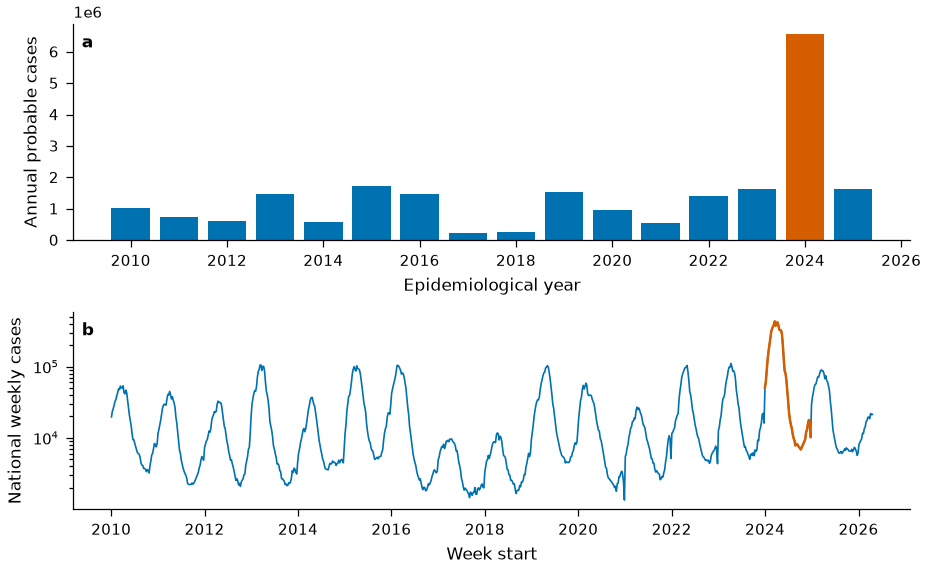

,probable_cases
ew_year,
2010,"1,015,861"
2011,"743,886"
2012,"597,901"
2013,"1,464,453"
2014,"588,250"
2015,"1,720,095"
2016,"1,484,901"
2017,"240,833"
2018,"266,414"


,probable_cases_by_season_end_year
season_end_year,
2011,"769,295"
2012,"587,003"
2013,"1,485,600"
2014,"567,970"
2015,"1,586,977"
2016,"1,638,593"
2017,"251,940"
2018,"242,983"
2019,"1,520,475"


In [6]:
annual = dengue.groupby("ew_year")["cases"].sum().loc[2010:2025]
baseline_years = annual.loc[2010:2023]
cases_2024 = int(annual.loc[2024])
prev_max_year = int(baseline_years.idxmax())
prev_max_cases = int(baseline_years.max())
ratio_to_prev_max = cases_2024 / prev_max_cases
ratio_to_median = cases_2024 / float(baseline_years.median())

seasons_covering_2024 = sorted(
    dengue.loc[dengue["ew_year"] == 2024, "season_end_year"].unique().tolist()
)
season_totals = (
    dengue.groupby("season_end_year")["cases"]
    .sum()
    .loc[lambda s: s.index.isin(complete_seasons)]
    .sort_index()
)

national_weekly = dengue.groupby("week_start", as_index=False)["cases"].sum()
national_weekly = pd.concat(
    [national_weekly, epiweek_of(national_weekly["week_start"])], axis=1
)

print(
    f"2024 totalled {cases_2024:,} probable cases — "
    f"{ratio_to_prev_max:.1f}× the previous annual maximum ({prev_max_cases:,} in "
    f"{prev_max_year}) and {ratio_to_median:.1f}× the 2010–2023 median."
)
print(
    f"Calendar 2024 weeks fall in dengue season_end_year(s) {seasons_covering_2024}; "
    f"held-out seasons for eval are {held_out}."
)

fig, axes = plt.subplots(
    2, 1, figsize=(7.2, 4.2), sharex=False, gridspec_kw={"height_ratios": [1.1, 1], "hspace": 0.35}
)

colors = ["#D55E00" if year == 2024 else "#0072B2" for year in annual.index]
axes[0].bar(annual.index.astype(int), annual.values, color=colors, width=0.8)
axes[0].set_ylabel("Annual probable cases")
axes[0].set_xlabel("Epidemiological year")
axes[0].text(0.01, 0.95, "a", transform=axes[0].transAxes, fontweight="bold", va="top")

axes[1].plot(
    national_weekly["week_start"],
    national_weekly["cases"],
    color="#0072B2",
    lw=0.8,
)
mask_2024 = national_weekly["ew_year"] == 2024
axes[1].plot(
    national_weekly.loc[mask_2024, "week_start"],
    national_weekly.loc[mask_2024, "cases"],
    color="#D55E00",
    lw=1.2,
)
axes[1].set_ylabel("National weekly cases")
axes[1].set_xlabel("Week start")
axes[1].set_yscale("log")
axes[1].text(0.01, 0.95, "b", transform=axes[1].transAxes, fontweight="bold", va="top")

fig.savefig(FIGURES_DIR / "eda_2024_anomaly.pdf")
fig.savefig(FIGURES_DIR / "eda_2024_anomaly.png")
plt.show()

display(annual.map("{:,.0f}".format).to_frame("probable_cases"))
display(season_totals.map("{:,.0f}".format).to_frame("probable_cases_by_season_end_year"))

### 4. Non-stationarity (qualitative)

The series are not weakly stationary in the classical sense: the conditional mean
follows an annual epidemic cycle, and epidemic amplitude changes across years
(extreme seasons above). We do **not** run ADF/KPSS here — on overdispersed seasonal
counts those tests mainly reject for seasonality and level shifts, not because they
identify a useful differencing order. Phase 1 already targets the forecast-relevant
forms via `log1p`, seasonal period `m = 52` / Fourier terms, and named extreme seasons —
not by claiming stationarity after transformation.

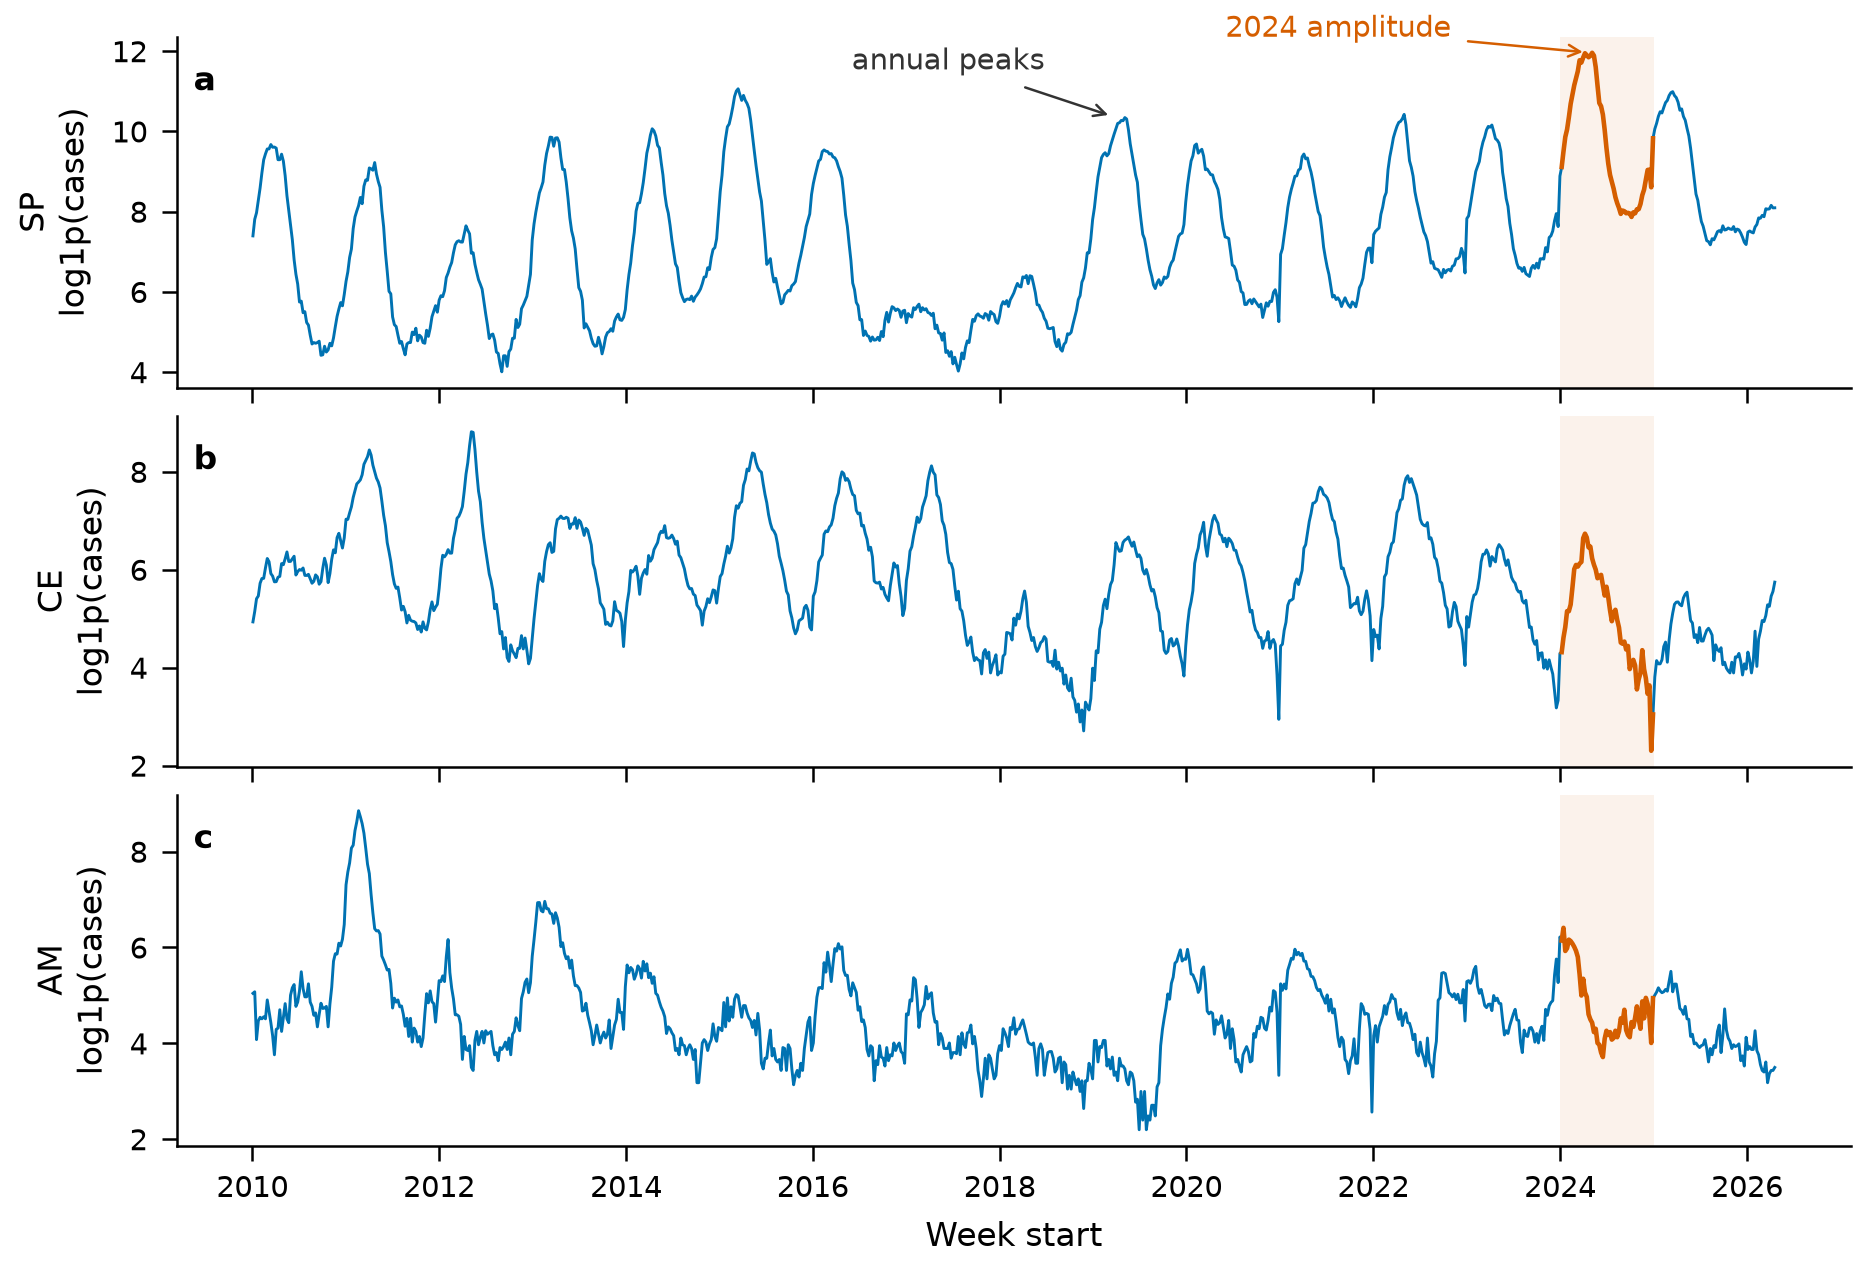

Same pattern across UFs: repeating seasonal peaks (non-constant mean within the year) and year-to-year amplitude shifts (2024 highlighted) — classical weak stationarity does not hold; Phase 1 models around that rather than unit-root testing it.


In [5]:
# Three UFs: high South-East burden, Northeast, North — same qualitative pattern.
STATIONARITY_UFS = ("SP", "CE", "AM")
band_2024 = (
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
)

fig, axes = plt.subplots(
    len(STATIONARITY_UFS),
    1,
    figsize=(7.2, 4.8),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)

for ax, uf, panel in zip(axes, STATIONARITY_UFS, "abc"):
    series = (
        dengue.loc[dengue["uf"] == uf, ["week_start", "log1p_cases"]]
        .sort_values("week_start")
    )
    ax.plot(series["week_start"], series["log1p_cases"], color="#0072B2", lw=0.7)
    in_2024 = series["week_start"].between(*band_2024)
    ax.plot(
        series.loc[in_2024, "week_start"],
        series.loc[in_2024, "log1p_cases"],
        color="#D55E00",
        lw=1.1,
    )
    ax.axvspan(*band_2024, color="#D55E00", alpha=0.08, lw=0)
    ax.set_ylabel(f"{uf}\nlog1p(cases)")
    ax.text(0.01, 0.92, panel, transform=ax.transAxes, fontweight="bold", va="top")

axes[-1].set_xlabel("Week start")

# Annotate on SP only: seasonal peaks vs 2024 amplitude (data coordinates).
sp_peak_2019 = float(
    dengue.loc[
        (dengue["uf"] == "SP") & (dengue["ew_year"] == 2019), "log1p_cases"
    ].max()
)
sp_peak_2024 = float(
    dengue.loc[
        (dengue["uf"] == "SP") & (dengue["ew_year"] == 2024), "log1p_cases"
    ].max()
)
axes[0].annotate(
    "annual peaks",
    xy=(pd.Timestamp("2019-04-01"), sp_peak_2019),
    xytext=(pd.Timestamp("2016-06-01"), sp_peak_2019 + 1.2),
    fontsize=7,
    color="#333333",
    arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 0.6},
)
axes[0].annotate(
    "2024 amplitude",
    xy=(pd.Timestamp("2024-05-01"), sp_peak_2024),
    xytext=(pd.Timestamp("2020-06-01"), sp_peak_2024 + 0.4),
    fontsize=7,
    color="#D55E00",
    arrowprops={"arrowstyle": "->", "color": "#D55E00", "lw": 0.6},
)

fig.savefig(FIGURES_DIR / "eda_nonstationarity_examples.pdf")
fig.savefig(FIGURES_DIR / "eda_nonstationarity_examples.png")
plt.show()
print(
    "SP / CE / AM: seasonal peaks repeat every year (mean depends on calendar position) "
    "and peak height changes across years (2024 orange) — weak stationarity fails for "
    "reasons you can see; ADF would reject without telling us what to do next."
)

## Main figure — EW × year × UF heatmap

`log10(I + 1)` by epidemiological week and year, facets ordered west → east. One panel
shows seasonality, burden gradient, and the 2024 bright band under a shared colour scale.

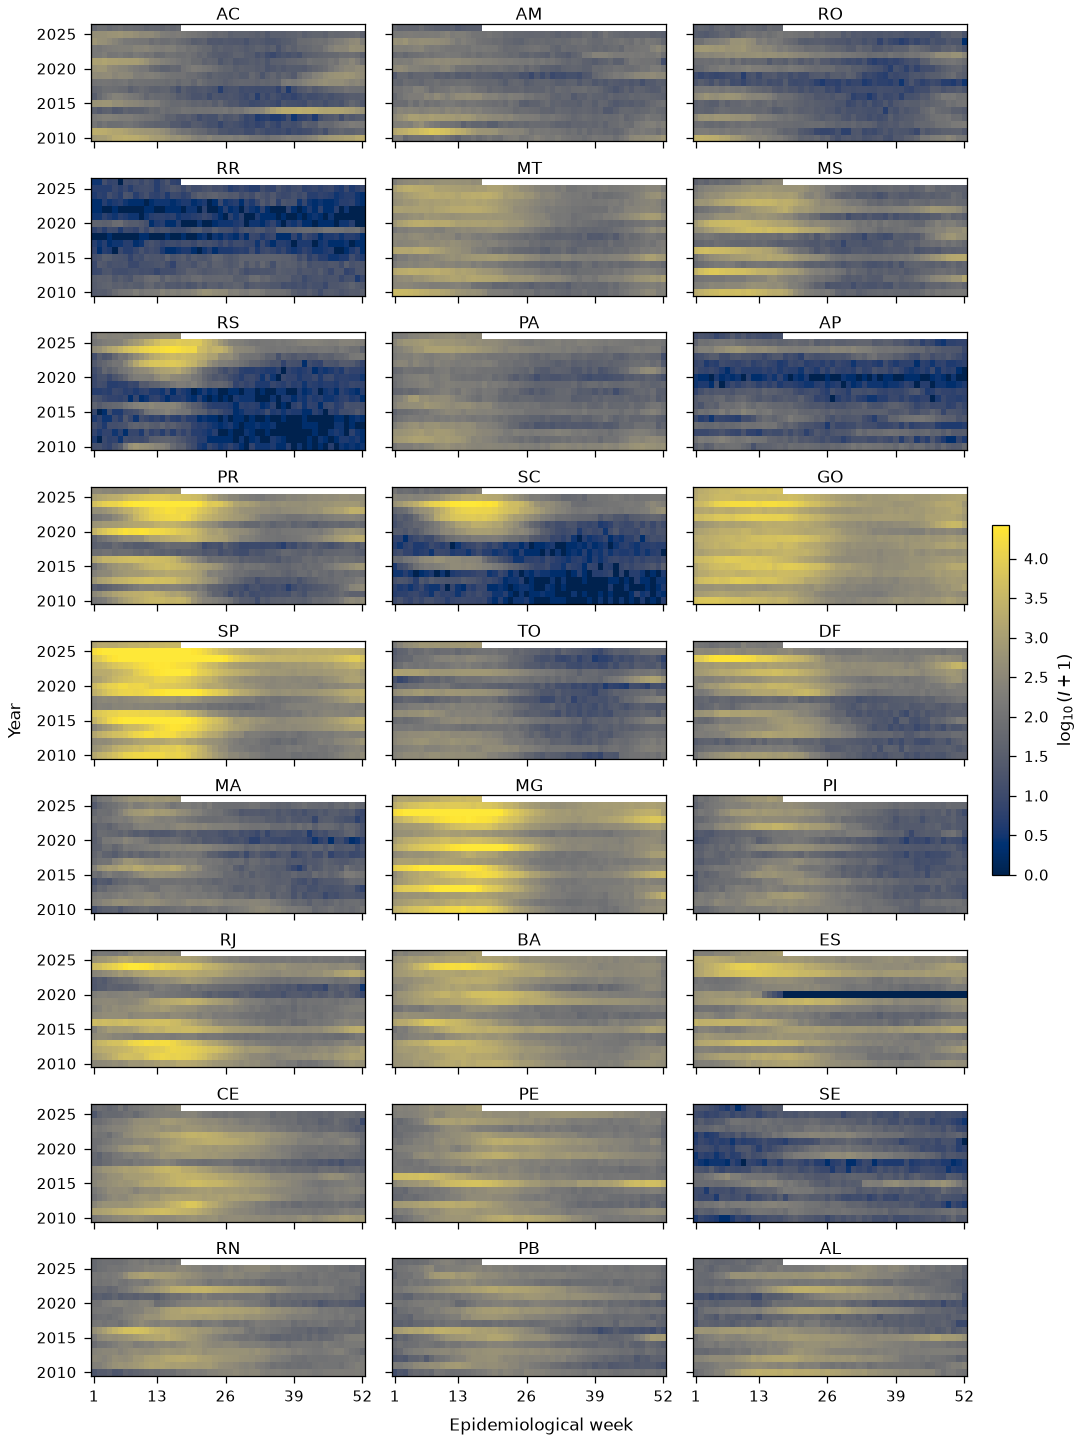

In [7]:
years = np.arange(dengue["ew_year"].min(), dengue["ew_year"].max() + 1)
ews = np.arange(1, 53)
vmax = dengue["log10_cases"].quantile(0.995)

n_ufs = len(UFS_WEST_TO_EAST)
n_cols = 3
n_rows = int(np.ceil(n_ufs / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7.2, 9.6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes_flat = np.asarray(axes).ravel()
cmap = plt.colormaps["cividis"]

last_mesh = None
for ax, uf in zip(axes_flat, UFS_WEST_TO_EAST):
    panel = (
        dengue.loc[dengue["uf"] == uf]
        .query("ew <= 52")
        .pivot_table(index="ew_year", columns="ew", values="log10_cases", aggfunc="mean")
        .reindex(index=years, columns=ews)
    )
    last_mesh = ax.pcolormesh(
        panel.columns.to_numpy(),
        panel.index.to_numpy(),
        panel.to_numpy(),
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        shading="nearest",
        rasterized=True,
    )
    ax.set_title(uf, pad=2)
    ax.set_xlim(0.5, 52.5)
    ax.spines.top.set_visible(True)
    ax.spines.right.set_visible(True)

for ax in axes_flat[n_ufs:]:
    ax.set_visible(False)

for ax in axes_flat[:n_ufs]:
    ax.set_xticks([1, 13, 26, 39, 52])

fig.supxlabel("Epidemiological week", fontsize=8)
fig.supylabel("Year", fontsize=8)
cbar = fig.colorbar(last_mesh, ax=axes_flat[:n_ufs], fraction=0.02, pad=0.02)
cbar.set_label(r"$\log_{10}(I + 1)$")

fig.savefig(FIGURES_DIR / "eda_uf_ew_year_heatmap.pdf")
fig.savefig(FIGURES_DIR / "eda_uf_ew_year_heatmap.png")
plt.show()

## Enrichment — incidence heatmap (cases per million)

Same EW × year layout as above, but weekly rates per million inhabitants using IBGE
2024 UF population estimates (SIDRA table 6579, reference date 2024-07-01) as a fixed
denominator. Informative only: shows relative intensity after population size; not used
for modelling or scoring.

IBGE UF population 2024 (n=27): total 212,583,750; source data/external/ibge_uf_population_2024.csv
Weekly cases/million — median 28.72, p99 1355.1, max 7670.6


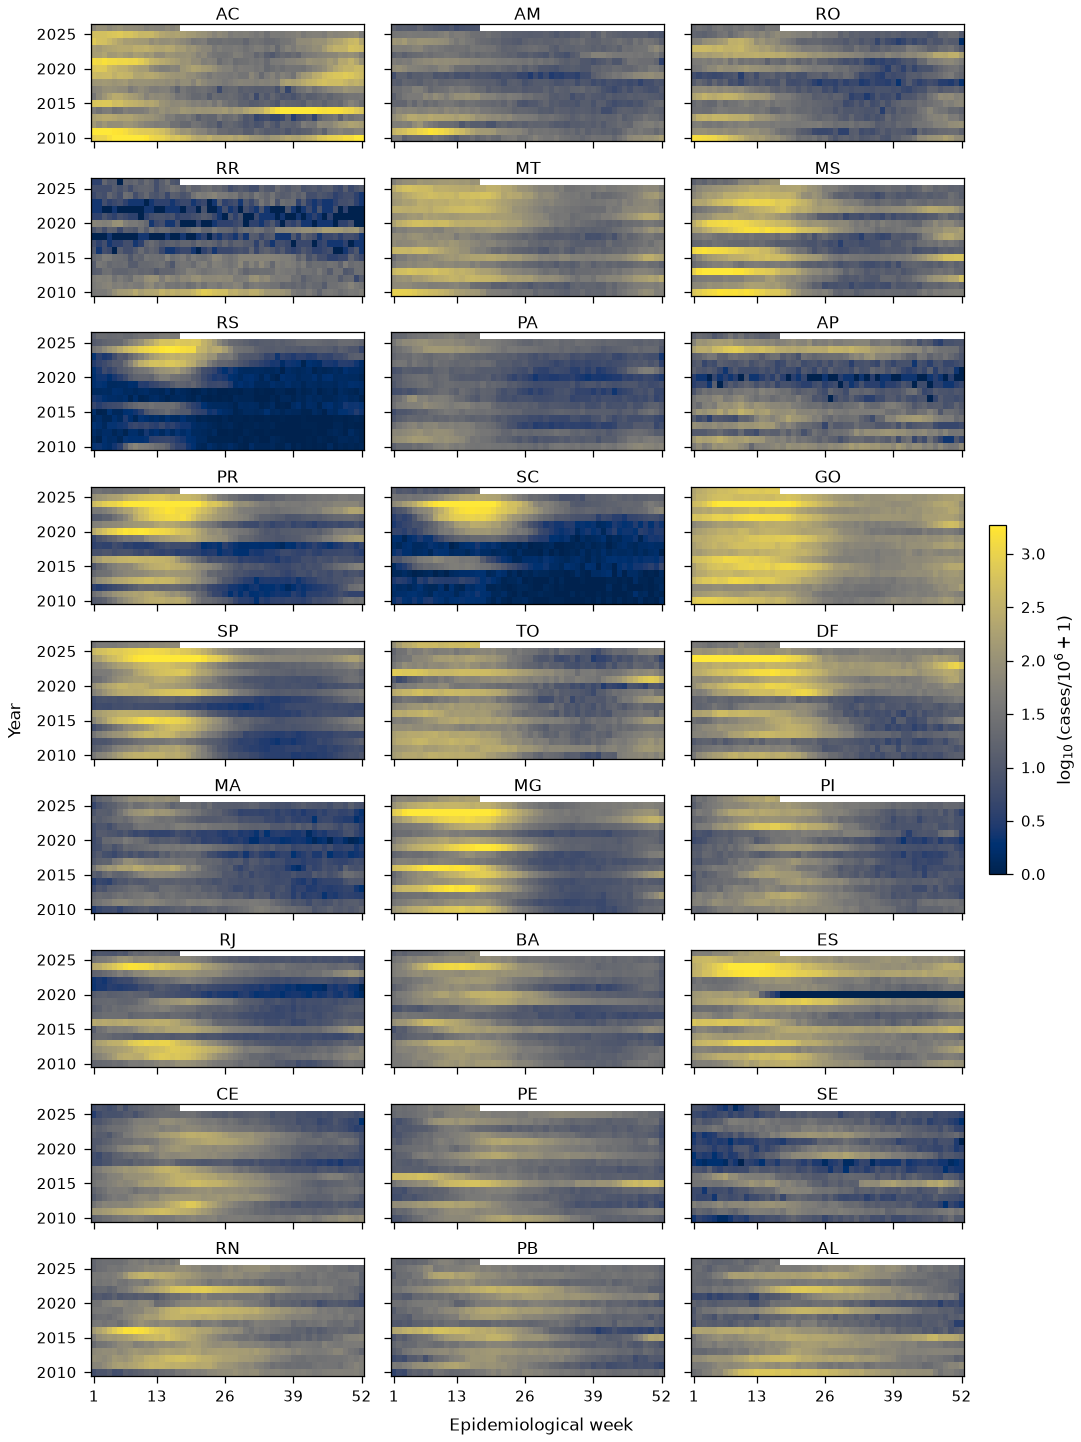

,uf_name,population
uf,,
AC,Acre,880631
AM,Amazonas,4281209
RO,Rondônia,1746227
RR,Roraima,716793
MT,Mato Grosso,3836399
MS,Mato Grosso do Sul,2901895
RS,Rio Grande do Sul,11229915
PA,Pará,8664306
AP,Amapá,802837


In [8]:
POPULATION_PATH = REPO_ROOT / config["data"]["ibge_population"]["path"]
population = pd.read_csv(POPULATION_PATH)
assert set(population["uf"]) == set(UFS_WEST_TO_EAST), "UF mismatch vs panel"

dengue_rate = dengue.merge(population[["uf", "population"]], on="uf", how="left", validate="many_to_one")
assert dengue_rate["population"].notna().all()
dengue_rate["cases_per_million"] = dengue_rate["cases"] * 1_000_000 / dengue_rate["population"]
dengue_rate["log10_cases_per_million"] = np.log10(dengue_rate["cases_per_million"] + 1)

print(
    f"IBGE UF population 2024 (n={len(population)}): "
    f"total {int(population['population'].sum()):,}; "
    f"source {POPULATION_PATH.relative_to(REPO_ROOT)}"
)
print(
    "Weekly cases/million — "
    f"median {dengue_rate['cases_per_million'].median():.2f}, "
    f"p99 {dengue_rate['cases_per_million'].quantile(0.99):.1f}, "
    f"max {dengue_rate['cases_per_million'].max():.1f}"
)

years = np.arange(dengue_rate["ew_year"].min(), dengue_rate["ew_year"].max() + 1)
ews = np.arange(1, 53)
vmax_rate = dengue_rate["log10_cases_per_million"].quantile(0.995)

n_ufs = len(UFS_WEST_TO_EAST)
n_cols = 3
n_rows = int(np.ceil(n_ufs / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7.2, 9.6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes_flat = np.asarray(axes).ravel()
cmap = plt.colormaps["cividis"]

last_mesh = None
for ax, uf in zip(axes_flat, UFS_WEST_TO_EAST):
    panel = (
        dengue_rate.loc[dengue_rate["uf"] == uf]
        .query("ew <= 52")
        .pivot_table(
            index="ew_year",
            columns="ew",
            values="log10_cases_per_million",
            aggfunc="mean",
        )
        .reindex(index=years, columns=ews)
    )
    last_mesh = ax.pcolormesh(
        panel.columns.to_numpy(),
        panel.index.to_numpy(),
        panel.to_numpy(),
        cmap=cmap,
        vmin=0,
        vmax=vmax_rate,
        shading="nearest",
        rasterized=True,
    )
    ax.set_title(uf, pad=2)
    ax.set_xlim(0.5, 52.5)
    ax.spines.top.set_visible(True)
    ax.spines.right.set_visible(True)

for ax in axes_flat[n_ufs:]:
    ax.set_visible(False)

for ax in axes_flat[:n_ufs]:
    ax.set_xticks([1, 13, 26, 39, 52])

fig.supxlabel("Epidemiological week", fontsize=8)
fig.supylabel("Year", fontsize=8)
cbar = fig.colorbar(last_mesh, ax=axes_flat[:n_ufs], fraction=0.02, pad=0.02)
cbar.set_label(r"$\log_{10}(\mathrm{cases}/10^6 + 1)$")

fig.savefig(FIGURES_DIR / "eda_uf_ew_year_heatmap_per_million.pdf")
fig.savefig(FIGURES_DIR / "eda_uf_ew_year_heatmap_per_million.png")
plt.show()

population.set_index("uf").loc[UFS_WEST_TO_EAST, ["uf_name", "population"]]

## Takeaways (article-ready)

Numbers below are computed from the cells above. Paper figure:
`docs/figures/eda_uf_ew_year_heatmap.pdf`.

In [9]:
print(
    "1. Overdispersion — weekly VMR ranges "
    f"{vmr_min:.0f}–{vmr_max:,.0f} across UFs "
    f"(median {vmr_median:,.0f}) → model and score on log1p; "
    "never headline MAE on raw counts."
)
print(
    "2. Annual periodicity — seasonal peak at "
    f"EW{peak_ew} (trough EW{trough_ew}); median UF autocorr "
    f"{acf52_median:.2f} at lag 52 vs {acf26_median:.2f} at lag 26 "
    "→ seasonal naive and Fourier seasonality with m = 52."
)
print(
    "3. Extreme seasons — calendar 2024 is "
    f"{ratio_to_prev_max:.1f}× the prior annual maximum "
    f"(season_end_year(s) {seasons_covering_2024}; held-out {held_out}) "
    "→ name the extreme regime when reading skill; do not drop it from evaluation."
)
print(
    "4. Non-stationarity — seasonal mean cycle + year-to-year amplitude shifts "
    "(illustrated for SP, CE, AM) → no ADF/KPSS; Phase 1 uses log1p and m = 52 / "
    "Fourier rather than unit-root differencing."
)

1. Overdispersion — weekly VMR ranges 105–44,933 across UFs (median 1,129) → model and score on log1p; never headline MAE on raw counts.
2. Annual periodicity — seasonal peak at EW15 (trough EW39); median UF autocorr 0.51 at lag 52 vs -0.13 at lag 26 → seasonal naive and Fourier seasonality with m = 52.
3. Extreme seasons — calendar 2024 is 3.8× the prior annual maximum (season_end_year(s) [2024, 2025]; held-out [2024, 2025]) → name the extreme regime when reading skill; do not drop it from evaluation.
4. Non-stationarity — seasonal mean cycle + year-to-year amplitude shifts (illustrated for SP, CE, AM) → no ADF/KPSS; Phase 1 uses log1p and m = 52 / Fourier rather than unit-root differencing.
